In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import os

In [ ]:
print(os.listdir('/kaggle/input'))

In [ ]:


print("Inside notebooks:")
print(os.listdir('/kaggle/input/notebooks'))

print("\nInside datasets:")
print(os.listdir('/kaggle/input/datasets'))

In [ ]:


path = "/kaggle/input/datasets/aryashah2k"

print(os.listdir(path))

In [ ]:
import os

for dirname, _, filenames in os.walk("/kaggle/input/datasets/aryashah2k"):
    print(dirname)
    

In [ ]:
import os

datasets = os.listdir('/kaggle/input')

print("Number of top-level inputs:", len(datasets))
print("\nInputs:")
for d in datasets:
    print("-", d)
    

In [ ]:
import os

dataset_folders = []

for dirname, dirnames, filenames in os.walk('/kaggle/input'):
    if dirnames:
        continue
    dataset_folders.append(dirname)

print("Total folders found:", len(dataset_folders))

for folder in dataset_folders:
    print(folder)
    

In [ ]:

print(os.listdir('/kaggle/input/datasets/aryashah2k'))

In [ ]:

dataset_path = "/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset"

classes = sorted(os.listdir(dataset_path))

print("Total Plant Classes:", len(classes))

for plant in classes:
    print(plant)

In [ ]:

for plant in sorted(os.listdir(dataset_path)):
    
    plant_folder = os.path.join(dataset_path, plant)

    if os.path.isdir(plant_folder):
        print(
            plant,
            ":",
            len(os.listdir(plant_folder))
        )

In [ ]:
import pandas as pd
import os

data = []

for plant in sorted(os.listdir(dataset_path)):
    
    folder = os.path.join(dataset_path, plant)

    if os.path.isdir(folder):
        data.append([
            plant,
            len(os.listdir(folder))
        ])

df = pd.DataFrame(
    data,
    columns=["Plant Name","Image Count"]
)

df

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.bar(
    df["Plant Name"],
    df["Image Count"]
)

plt.xticks(rotation=90)
plt.title("Medicinal Plant Dataset Distribution")
plt.show()

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(12,8))

for i, plant in enumerate(classes[:9]):
    
    folder = os.path.join(dataset_path, plant)

    img_file = os.listdir(folder)[0]

    img_path = os.path.join(folder, img_file)

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(plant)
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Import Libraries **

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/kaggle/input/datasets/aryashah2k/indian-medicinal-leaves-dataset/Indian Medicinal Leaves Image Datasets/Medicinal plant dataset"

# Create Image Preprocessing Pipeline

In [7]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Create Training Dataset

In [8]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 4765 images belonging to 40 classes.


# Create Validation Dataset

In [9]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1180 images belonging to 40 classes.


# Verify Class Labels

In [10]:
print(train_data.class_indices)

{'Aloevera': 0, 'Amla': 1, 'Amruta_Balli': 2, 'Arali': 3, 'Ashoka': 4, 'Ashwagandha': 5, 'Avacado': 6, 'Bamboo': 7, 'Basale': 8, 'Betel': 9, 'Betel_Nut': 10, 'Brahmi': 11, 'Castor': 12, 'Curry_Leaf': 13, 'Doddapatre': 14, 'Ekka': 15, 'Ganike': 16, 'Gauva': 17, 'Geranium': 18, 'Henna': 19, 'Hibiscus': 20, 'Honge': 21, 'Insulin': 22, 'Jasmine': 23, 'Lemon': 24, 'Lemon_grass': 25, 'Mango': 26, 'Mint': 27, 'Nagadali': 28, 'Neem': 29, 'Nithyapushpa': 30, 'Nooni': 31, 'Pappaya': 32, 'Pepper': 33, 'Pomegranate': 34, 'Raktachandini': 35, 'Rose': 36, 'Sapota': 37, 'Tulasi': 38, 'Wood_sorel': 39}


# After Preprocessing
Medicinal Plant Identification Model
# MobileNetV2

In [11]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
print("MobileNetV2 Loaded Successfully")

MobileNetV2 Loaded Successfully


# Building the Medicinal Plant Identification Model
Model Architecture Design using MobileNetV2

A MobileNetV2-based Convolutional Neural Network (CNN) architecture was developed for medicinal plant identification. MobileNetV2 acts as the feature extractor, while additional dense layers perform classification of the extracted features into 40 medicinal plant categories. A dropout layer was incorporated to reduce overfitting and improve model generalization.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(40, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,200 (9.90 MB)

 Trainable params: 2,562,088 (9.77 MB)

 Non-trainable params: 34,112 (133.25 KB)

#  6. Model Compilation

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")


Model Compiled Successfully


# 7. Model Training

In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5


2026-09-10 20:05:17.387283: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-10 20:05:17.524841: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789070737.661743     135 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  3/149 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step - accuracy: 0.0278 - loss: 3.8825     

2026-09-10 20:05:54.844632: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-10 20:05:54.982181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.4675 - loss: 2.0438

2026-09-10 20:07:02.131301: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-10 20:07:02.267613: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


149/149 ━━━━━━━━━━━━━━━━━━━━ 148s 569ms/step - accuracy: 0.6378 - loss: 1.3361 - val_accuracy: 0.1008 - val_loss: 13.1965
Epoch 2/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 20s 130ms/step - accuracy: 0.8581 - loss: 0.5084 - val_accuracy: 0.0373 - val_loss: 25.1915
Epoch 3/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - accuracy: 0.8986 - loss: 0.3317 - val_accuracy: 0.0466 - val_loss: 23.1973
Epoch 4/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.9203 - loss: 0.2711 - val_accuracy: 0.0500 - val_loss: 19.0094
Epoch 5/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.9263 - loss: 0.2647 - val_accuracy: 0.0322 - val_loss: 23.6507


In [15]:
model.save("medicinal_plant_identifier.keras")

In [16]:

import os
print(os.listdir("/kaggle/working"))

['.virtual_documents', 'medicinal_plant_identifier.keras']


In [17]:
%who

BATCH_SIZE	 Dense	 Dropout	 GlobalAveragePooling2D	 IMG_SIZE	 ImageDataGenerator	 MobileNetV2	 Sequential	 base_model	 
datagen	 dataset_path	 history	 model	 os	 tf	 train_data	 val_data	 


In [18]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


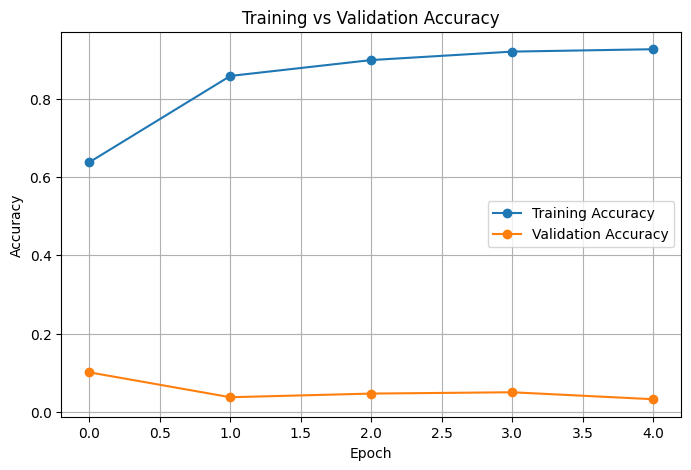

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.grid(True)

plt.show()

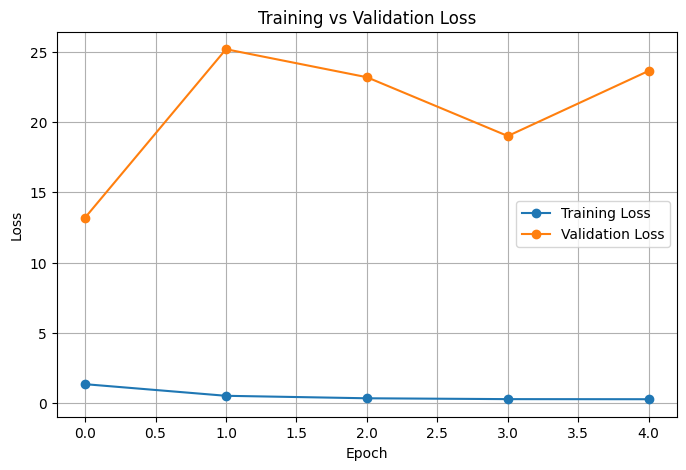

In [20]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.grid(True)

plt.show()

In [22]:
import os
print(os.listdir("/kaggle/working"))

['.virtual_documents', 'medicinal_plant_identifier.keras']


In [23]:
import os

file_path = "/kaggle/working/medicinal_plant_identifier.keras"

print("Size (MB):", os.path.getsize(file_path)/(1024*1024))

Size (MB): 30.12356472015381


In [24]:
from tensorflow.keras.models import load_model

loaded_model = load_model("/kaggle/working/medicinal_plant_identifier.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [25]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/working/medicinal_plant_identifier.keras")

In [1]:
import tensorflow as tf

print("GPUs Available:", tf.config.list_physical_devices('GPU'))

GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
